# Example of usage of waveguide code

First we import a geometry (either gmsh or ngsolve based) along with the labels of its boundary regions

In [80]:
R = 2.
H = 1.

NGSOLVE = True

lc = 0.2

# if NGSOLVE:
#     from cases.waveguide.ngsolve_geometries import Empty, WaveguideRegions
#     mesh = Empty(R=R, H=H, verbosity=0, lc=lc)
# else:
#     from cases.waveguide.gmsh_geometries import Empty, WaveguideRegions
#     mesh = Empty(R=R, H=H, verbose=True, lc=lc)


In [81]:
from cases.waveguide.base import CleanWaveguide

waveguide = CleanWaveguide(R=R, H=H, lc=lc)

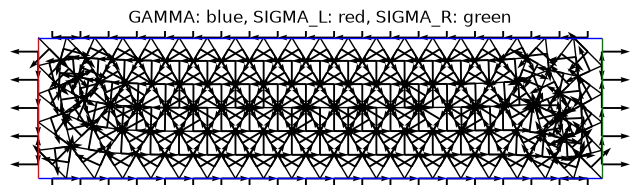

In [82]:
waveguide.plot()

In [83]:
list(waveguide.mesh.boundary_regions)

[<BoundaryRegions.GAMMA: 'Gamma'>,
 <BoundaryRegions.SIGMA_L: 'Sigma_L'>,
 <BoundaryRegions.SIGMA_R: 'Sigma_R'>]

To that regions we can apply different boundary conditions. In our case we will set a radianting boundary condition both in $\Sigma_L$ and $\Sigma_R$, and a _soundhard_ boundary condition at $\Gamma$.

The boundary conditions are just a dictionary:

In [84]:
from trefftz.dg.boundary_conditions import SoundHardBC, NtDBC

In [85]:
from cases.waveguide.NeumannToDirichlet import Mode, PropagationDirection
k = 8.0
t = 2
mode = Mode(k, H, t, direction=PropagationDirection.RIGHT)
boundary_conditions = {waveguide.mesh.boundary_regions.GAMMA: SoundHardBC(),
                       waveguide.mesh.boundary_regions.SIGMA_L: NtDBC(truncating_radius=R, data=1.), #I need to refine this, right now "data" is nonsense
                       waveguide.mesh.boundary_regions.SIGMA_R: NtDBC(truncating_radius=R, data=1.)}

Each boundary condition corresponds to a given kernel (this perhaps should be a default). There are general kernels for _soundhard_ or _transmission_ kernels:

In [86]:
from trefftz.dg.serial_fluxes import UltraWeakFlux, NeumannFlux


as well as specific ones (for the waveguide):

In [87]:
from cases.waveguide.serial_fluxes import NtDLocal, NtDNonLocal

Now the numerics (the configuration of kernels) is almost a dictionary:

In [88]:
from trefftz.dg.assemblers import SerialNumerics

NtD_modes = 10

numerics = SerialNumerics(interior_kernel=UltraWeakFlux(a=0.5, b=0.5),
                          local_boundary_kernels={SoundHardBC: NeumannFlux(d_1=0.5),
                                                  NtDBC: NtDLocal(d_2=0.5, NtD_modes=NtD_modes, data=mode)},
                          nonlocal_boundary_kernels={NtDBC: NtDNonLocal(H=H, d_2=0.5, NtD_modes=NtD_modes, data=mode)})

# numerics = SerialNumerics(interior_kernel=UltraWeakFlux(a=0.5, b=0.5),
#                           local_boundary_kernels={SoundHardBC: NeumannFlux(d_1=0.5),
#                                                   NtDBC: NtDLocal(R=R, d_2=0.5, data=mode)},
#                           nonlocal_boundary_kernels={})

We should also choose a local basis

In [89]:
from trefftz.dg.basis import LinearlySpacedBasis
N_theta = 15
basis = LinearlySpacedBasis(N_elements=waveguide.mesh.n_triangles, k=k, N_theta=N_theta)
basis.N_DOF

3630

and an assembler:

In [90]:
from trefftz.dg.assemblers import SerialAssembler

assembler = SerialAssembler(mesh=waveguide.mesh, boundary_conditions=boundary_conditions, numerics=numerics, basis=basis)

so we can set the problem:

In [91]:
from trefftz.problem import Problem
P = Problem(mesh=waveguide.mesh, wavenumber=k, basis=basis, boundary_conditions=boundary_conditions, assembler=assembler, direct_solver=True)  #, numerics=numerics)

In [92]:
A = P.assemble_LHS()

assembling local operators
region: Gamma


100%|██████████| 40/40 [00:00<00:00, 129.95edge/s]


region: Sigma_L


100%|██████████| 5/5 [00:00<00:00, 167.98edge/s]


region: Sigma_R


Interior: 100%|██████████| 338/338 [00:16<00:00, 20.53edge/s]


assembling non-local operators


NtD, Sigma_R: 100%|██████████| 5/5 [00:14<00:00,  2.90s/edge]


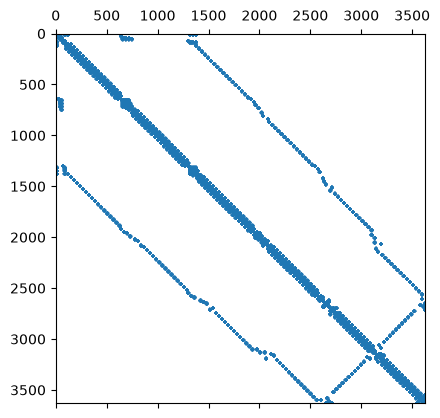

In [93]:
import matplotlib.pyplot as plt 
plt.spy(A, markersize=0.1)

In [105]:
assembler._regions_RHS_term

[<BoundaryRegions.SIGMA_L: 'Sigma_L'>, <BoundaryRegions.SIGMA_R: 'Sigma_R'>]

In [106]:
b = P.assemble_RHS()

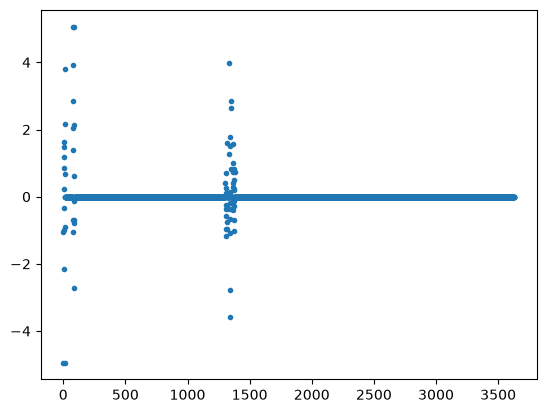

In [107]:
plt.plot(b.real,'.')

In [108]:
import numpy as np
np.count_nonzero(b)/N_theta

np.float64(9.933333333333334)

In [109]:
P.solve()

In [110]:
P.u_h.coefficients.reshape((-1, N_theta))

array([[ 0.06518922-0.02335857j,  0.01500969+0.08688111j,
         0.35847326+0.34366785j, ...,  0.01992614+0.07765827j,
         0.34593295+0.35433662j,  0.00631821+0.08739393j],
       [ 0.06095824+0.03737424j,  0.02254375-0.08730089j,
         0.36025404-0.34508548j, ..., -0.01049575-0.07263075j,
         0.36760005-0.33879382j,  0.02751537-0.08647228j],
       [ 0.0489039 +0.01732858j,  0.00872661-0.0708258j ,
         0.34128863-0.33971535j, ...,  0.00834094-0.0896946j ,
         0.34188593-0.33920157j,  0.00802486-0.07088235j],
       ...,
       [-0.01286483+0.0309906j , -0.04406184+0.03700147j,
         0.30896118+0.35763208j, ..., -0.09824974+0.01961491j,
         0.4175239 +0.21227095j,  0.03452104-0.04185816j],
       [-0.00477711+0.06130967j, -0.03687801+0.07167104j,
         0.34495282+0.34743937j, ..., -0.08321141+0.01496495j,
         0.43576178+0.22176754j,  0.04831922-0.06403413j],
       [ 0.0584289 +0.0343056j ,  0.02900187+0.08145542j,
         0.39213009+0.30301404

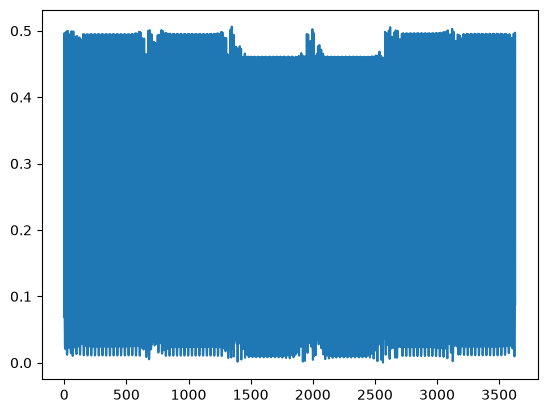

In [111]:
plt.plot(np.abs(P.u_h.coefficients))

In [112]:
import numpy as np
N = 200
x = np.linspace(-R, R, N)
y = np.linspace(0., H, int(N*H/R))
X, Y = np.meshgrid(x, y)
Z = P.u_h(X.ravel(), Y.ravel()).reshape(X.shape)

(0.0, 1.0)

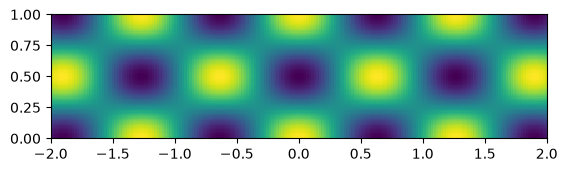

In [113]:
import matplotlib.pyplot as plt 
plt.pcolormesh(X, Y, Z.real)
plt.axis('square')
plt.xlim([-R, R])
plt.ylim([0., H])

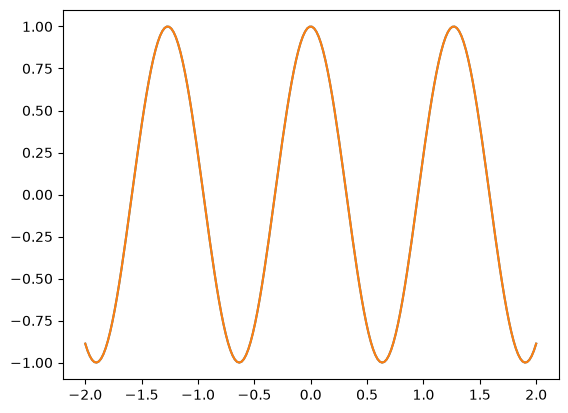

In [114]:
plt.plot(x,Z[0,:].real)
plt.plot(x,np.exp(1j*np.lib.scimath.sqrt(k**2 - (t*np.pi/H)**2)*x).real)

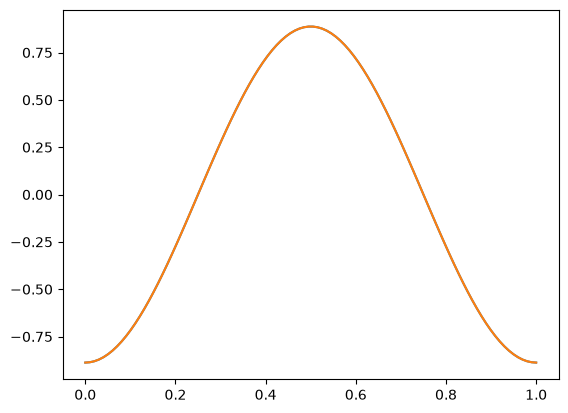

In [115]:
plt.plot(y,Z[:,0].real)
plt.plot(y,np.exp(-1j*np.lib.scimath.sqrt(k**2 - (t*np.pi/H)**2)*R).real*np.cos(t*np.pi/H*y))